In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import csv

In [ ]:
image_path = Path('.').parent / '../maps/cdc_2024/cdc_2024_edited_with_line.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")


Processing ../maps/cdc_2024/cdc_2024_edited_with_line.pgm...


## Load the image

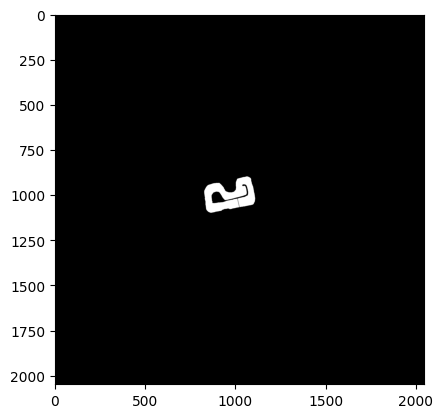

In [ ]:
img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Could not load image from {image_path}")
plt.imshow(img, cmap='gray')

In [ ]:
print(f"Loaded image with shape: {img.shape}")

# Threshold the image to create a binary image
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Invert if the track is white (assuming track is darker than background)
if np.mean(binary) > 127: # type: ignore
    binary = 255 - binary

Loaded image with shape: (2048, 2048)


In [ ]:
# Find contours - for boundary extraction
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)

1

In [ ]:
# Find the largest contour on the track
largest_contour = max(contours, key=cv2.contourArea)
print("Largest contour has shape:", largest_contour.shape)

Largest contour has shape: (355, 1, 2)


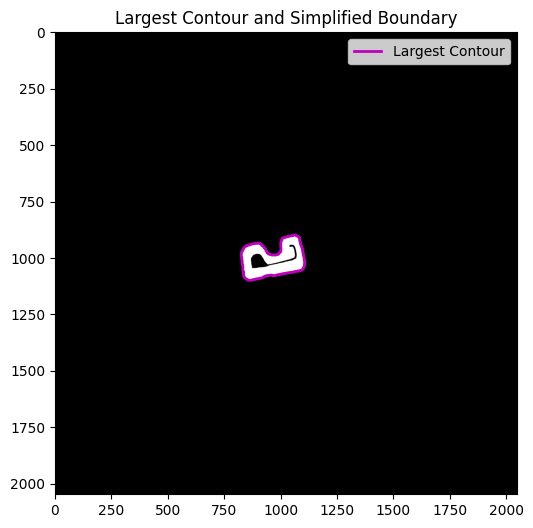

In [ ]:
boundary_points = largest_contour

# Extract coordinates for plotting
largest_contour_coords =    [(point[0][0], point[0][1]) for point in largest_contour] # type: ignore
boundary_coords =           [(point[0][0], point[0][1]) for point in boundary_points] # type: ignore

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
largest_x = [p[0] for p in largest_contour_coords]
largest_y = [p[1] for p in largest_contour_coords]
plt.plot(largest_x, largest_y, 'm-', linewidth=2, label='Largest Contour')

plt.title('Largest Contour and Simplified Boundary')
plt.legend()
plt.show()


In [ ]:

# Erode to create an artificial inner boundary
kernel = np.ones((3, 3), np.uint8)
eroded = cv2.erode(binary, kernel, iterations=3)  # Adjust iterations as needed

# Extract all contours with hierarchy using RETR_CCOMP
contours, hierarchy = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# Find the contour with the smallest area
inner_contour = None
if contours:
    inner_contour = min(contours, key=cv2.contourArea)
    # Optionally filter out tiny noise contours
    if cv2.contourArea(inner_contour) < 50:  # Adjust threshold as needed
        print("Smallest contour too small, might be noise.")
        inner_contour = None


In [ ]:
inner_contour  = inner_contour.reshape(-1, 2)  # type: ignore
inner_contour_coords = inner_contour
inner_contour_coords.shape

(271, 2)

In [ ]:
import numpy as np
import cv2

midpoints = []

# Convert contours to NumPy arrays
inner_array = np.array(inner_contour_coords)
outer_array = np.array(largest_contour_coords)

def does_line_cross_contour(p1, p2, contour):
    """
    Check if the line segment (p1 -> p2) intersects the given contour.
    """
    for i in range(len(contour)):
        q1 = contour[i]
        q2 = contour[(i + 1) % len(contour)]  # Wrap around
        if cv2.clipLine((q1[0], q1[1], q2[0], q2[1]), p1, p2):
            return True  # Line crosses the contour
    return False

for inner_point in inner_contour_coords:
    # Compute distances
    distances = np.linalg.norm(outer_array - np.array(inner_point), axis=1)

    # Sort indices by distance
    sorted_indices = np.argsort(distances)

    # Find the closest valid outer point (not crossing the track)
    for closest_index in sorted_indices:
        outer_point = largest_contour_coords[closest_index]
        
        # Check if the midpoint crosses the inner contour (i.e., the "wall")
        if not does_line_cross_contour(inner_point, outer_point, inner_array):
            # Compute midpoint
            midpoint_x = (inner_point[0] + outer_point[0]) / 2
            midpoint_y = (inner_point[1] + outer_point[1]) / 2
            midpoint = (midpoint_x, midpoint_y)

            midpoints.append(midpoint)
            print(f"Midpoint between {inner_point} and {outer_point} is {midpoint}")
            break  # Found a valid point, move to the next inner point


In [ ]:
# Skeletonize to get centerline
# Distance transform + adaptive thresholding
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

# Normalize for visualization
dist_norm = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX) # type: ignore

# Improve skeleton by using an adaptive threshold based on max distance
max_dist = np.max(dist_transform[binary > 0])  # Max distance within track
factor = 0.5 ## Factor
thresh_value = max_dist * factor  # Threshold at half the max distance (adjustable)
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY) # type: ignore
skeleton = skeleton.astype(np.uint8)

# Optional: Thin the skeleton with a single erosion step to refine it
kernel = np.ones((3, 3), np.uint8)
skeleton = cv2.erode(skeleton, kernel, iterations=1)

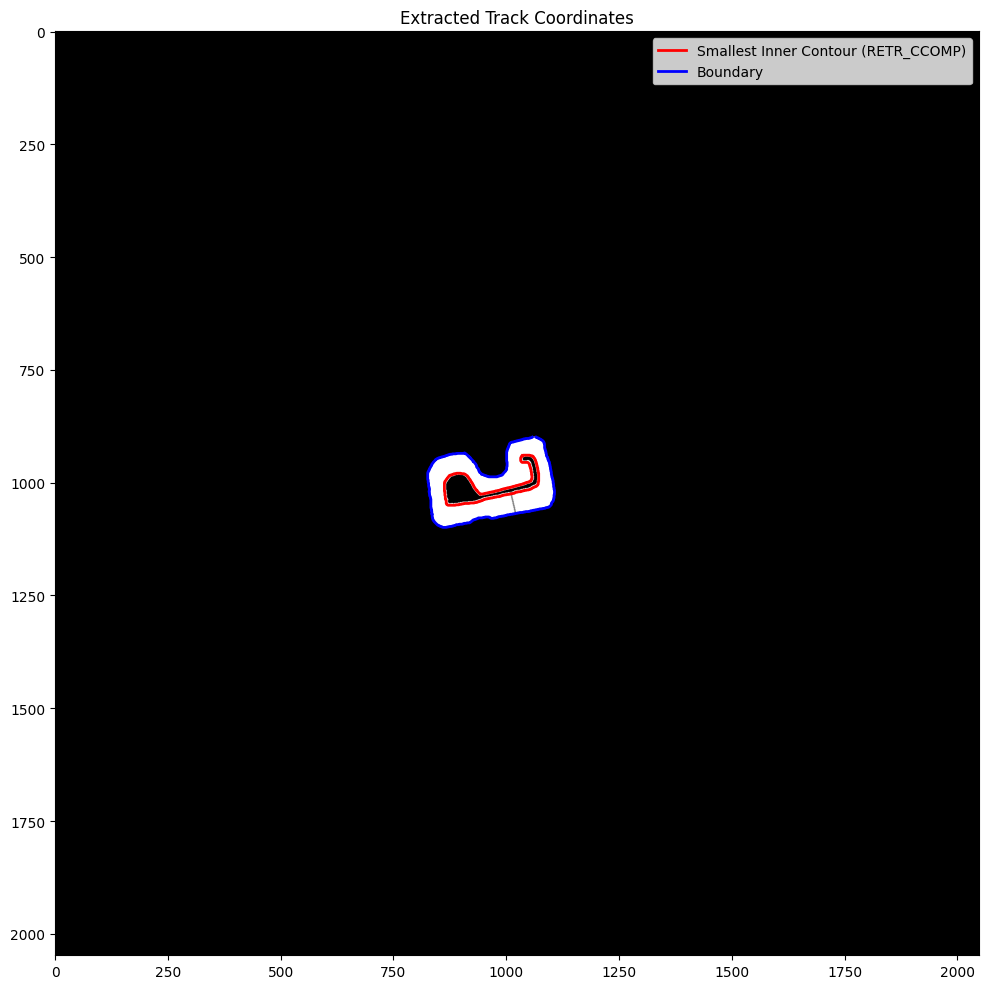

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualize results

plt.figure(figsize=(12, 10))

# Result with coordinates
plt.imshow(img, cmap='gray')

boundary_x = [p[0] for p in boundary_coords]
boundary_y = [p[1] for p in boundary_coords]

# if inner_contour_coords:
inner_x = [p[0] for p in inner_contour_coords]
inner_y = [p[1] for p in inner_contour_coords]
plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')

plt.plot(boundary_x, boundary_y, 'b-', linewidth=2, label='Boundary')
plt.title('Extracted Track Coordinates')
plt.legend()

plt.tight_layout()
plt.show()
if output_path:
    plt.savefig(output_path / 'track_with_coords.png')

## Adjust the Threshold Dynamically
Instead of a fixed max_dist * 0.5, try a lower or adaptive threshold to include more of the central region:


Using OpenCV thinning.


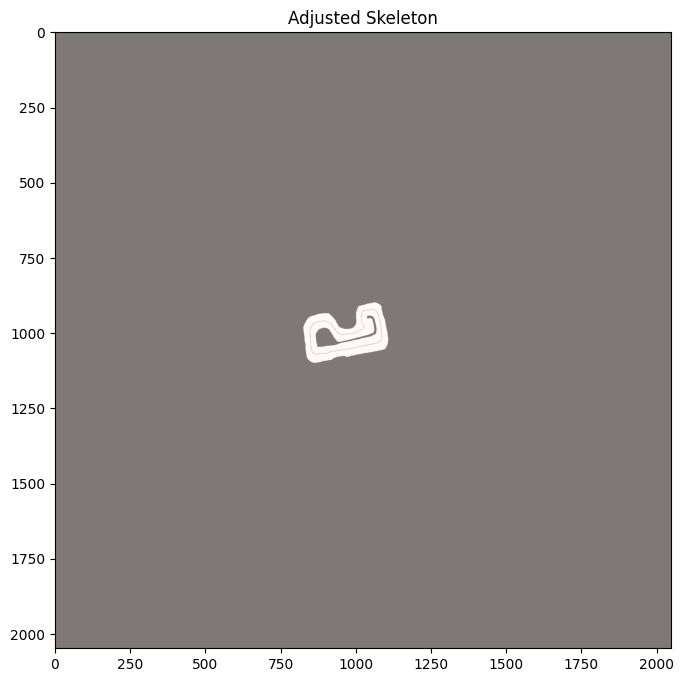

Skeleton pixels: 743


In [ ]:
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary > 0])
thresh_value = max_dist * 0.3  # Try 0.3 or 0.2 to widen the skeleton initially
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton = skeleton.astype(np.uint8)

# Optional: Thin it
try:
    import cv2
    skeleton = cv2.ximgproc.thinning(skeleton)  # Preferred if available
    print("Using OpenCV thinning.")
except ImportError:
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)

# Check result
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Adjusted Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

## Smooth the Binary Image First

If the track’s boundaries are jagged or uneven, smooth them before the distance transform:


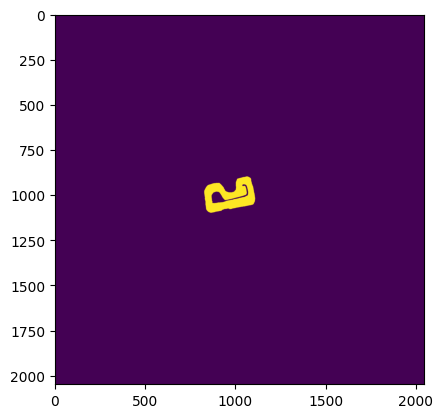

In [ ]:
# Smooth binary to even out boundaries
binary_smoothed = cv2.GaussianBlur(binary, (5, 5), 0)
_, binary_smoothed = cv2.threshold(binary_smoothed, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary_smoothed)

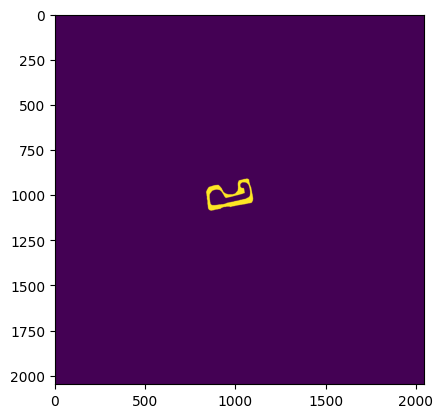

In [ ]:
dist_transform = cv2.distanceTransform(binary_smoothed, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary_smoothed > 0])
thresh_value = max_dist * 0.4  # Middle ground
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY) # type: ignore
skeleton = skeleton.astype(np.uint8)
plt.imshow(skeleton)

Used ximgproc OpenCV thinning.


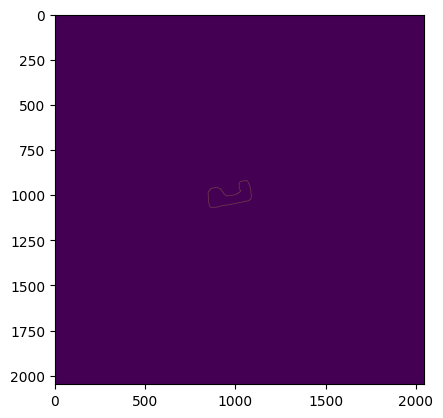

In [ ]:
# Thin it
try:
    skeleton = cv2.ximgproc.thinning(skeleton)
    print("Used ximgproc OpenCV thinning.")
except ImportError:
    print("Using basic thinning.")
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)
plt.imshow(skeleton)

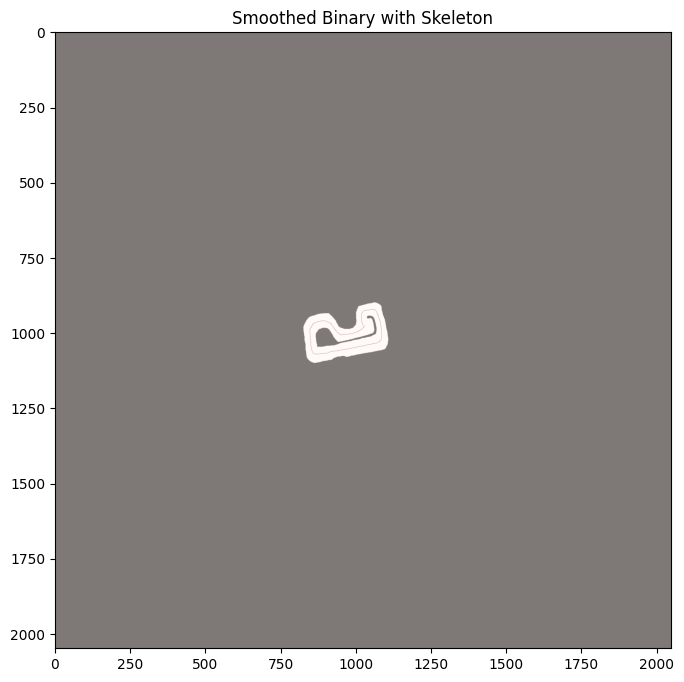

In [ ]:
y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'smoothed_binary_skeleton.png'), skeleton)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary_smoothed, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Smoothed Binary with Skeleton')
plt.show()

## Use a completely different approach with a Medial Axis Transform

The Medial Axis Transform (MAT) is a skeletonization algorithm that is based on the distance transform. The MAT is a thinning algorithm that reduces the binary image to its skeleton. The skeleton is a set of lines that are equidistant to the edges of the binary image. The MAT is a powerful tool for shape analysis and pattern recognition.

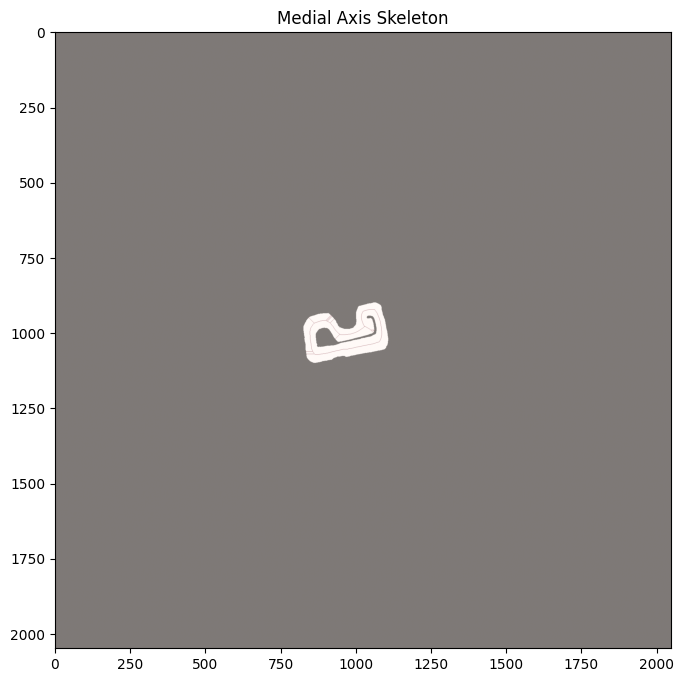

Skeleton pixels: 880


In [ ]:
from skimage.morphology import skeletonize, medial_axis
import numpy as np

# Convert binary to boolean (True for 255, False for 0)
binary_bool = binary > 0

# Medial axis transform (returns skeleton and distance)
skeleton, distance = medial_axis(binary_bool, return_distance=True)

# Convert back to uint8
skeleton = (skeleton * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Medial Axis Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'medial_axis_smoothed_skeleton.png'), skeleton)